# **Working with a dataset** 📂



---



In this notebook we are looking at a existing dataset and extract valuable information from it.

We also look at how to use an open source model for natural language labeling.

Also for that we will use an LLM, because we want to label 80,877 datapoints - an amount way to high to be label and created manually.

The dataset we look at is called rPlan:

https://docs.google.com/forms/d/e/1FAIpQLSfwteilXzURRKDI5QopWCyOGkeb_CFFbRwtQ0SOPhEg0KGSfw/viewform

This is code on github I have prepared for you to extract data from the dataset:

https://github.com/Cybernaut0815/rPlan_extraction

## Setup langchain and choose a model



---


Install langchain dependencies

In [1]:
from dotenv import load_dotenv
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_core.chat_history import BaseChatMessageHistory, InMemoryChatMessageHistory
from langchain_community.callbacks import get_openai_callback

import os

In [2]:
import subprocess
import time
import os
import signal

In [3]:
load_dotenv()  # Automatically searches for .env in current and parent directories

openai_api_key = os.getenv("OPENAI_API_KEY")
anthropic_api_key = os.getenv("ANTHROPIC_API_KEY")
goole_api_key = os.getenv("GOOGLE_API_KEY")


In [4]:
for key, value in [("OPENAI_API_KEY", openai_api_key), ("ANTHROPIC_API_KEY", anthropic_api_key), ("GOOGLE_API_KEY", goole_api_key)]:
    if value is not None:
        print(f"Environment variable {key} is set.")
    else:
        print(f"Environment variable {key} is NOT set.")

Environment variable OPENAI_API_KEY is set.
Environment variable ANTHROPIC_API_KEY is NOT set.
Environment variable GOOGLE_API_KEY is NOT set.




---


## **Simple chatbot inference over langchain**

In [5]:
# Create a ChatOpenAI model
llm = ChatOpenAI(model="gpt-5.2-chat-latest")

In [6]:
def promt_llm(prompt: str) -> str:
    response = llm.invoke([HumanMessage(content=prompt)])
    return response.content

In [7]:
promt = "Name 5 famous architects."

response = promt_llm(promt)
print(response)

Here are five famous architects from different eras and styles:

1. **Frank Lloyd Wright** – Known for organic architecture and designs like *Fallingwater*.
2. **Le Corbusier** – A pioneer of modern architecture and urban planning.
3. **Zaha Hadid** – Famous for futuristic, fluid designs and parametric architecture.
4. **Ludwig Mies van der Rohe** – Known for minimalist modernism and the phrase *“less is more.”*
5. **Antoni Gaudí** – Renowned for highly expressive works such as *Sagrada Família* in Barcelona.

If you'd like, I can list architects from a specific country or architectural style.



## **Working with a (partial) dataset**

___

The following code is based on the rPlan dataset which can be cloned here form my github:

In [8]:
!git clone https://github.com/Cybernaut0815/rPlan_extraction.git

Cloning into 'rPlan_extraction'...


Here we create a new folder for placing the dataset

In [10]:
!mkdir dataset

Then we can download the dataset to this folder

In [19]:
from huggingface_hub import snapshot_download

# Download the dataset
snapshot_download(repo_id="Cybernaut101/rPlan_subset_100", repo_type="dataset", local_dir=r".\dataset")

c:\Users\chris\Documents\RC10 Skill Module\RC10_2025\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 101 files: 100%|██████████| 101/101 [00:06<00:00, 15.78it/s]


'C:\\Users\\chris\\Documents\\RC10 Skill Module\\RC10_2025\\Lesson_3\\dataset'

Let's check, if we can find the images from the dataset:

In [21]:
paths = []
for filename in os.listdir('./dataset/'):
    if filename.endswith('.png') or filename.endswith('.jpg') or filename.endswith('.jpeg'):
        paths.append(f'./dataset/{filename}')

paths.sort()

In [22]:
print(paths[:10])

['./dataset/0.png', './dataset/1.png', './dataset/10.png', './dataset/11.png', './dataset/12.png', './dataset/13.png', './dataset/14.png', './dataset/15.png', './dataset/16.png', './dataset/17.png']




---

## **Visualizing & labeling the dataset**

In [26]:
import sys
import os

# Add rPlan_extraction directory to Python path to fix internal imports
rplan_path = os.path.abspath("./rPlan_extraction")
if rplan_path not in sys.path:
    sys.path.insert(0, rplan_path)
    print(f"Added {rplan_path} to sys.path")

from rPlan_extraction.helpers.info import Info
from rPlan_extraction.helpers.utils import load_image_paths
from rPlan_extraction.helpers.fp import Floorplan

from shapely.geometry import LineString, Polygon
import networkx as nx

This will basically create a class wrapping the information of the floorplan

In [29]:
wall_width = 3.0
my_fp = Floorplan(paths[0], wall_width=wall_width)

With this code we can visualize the connectivity graph

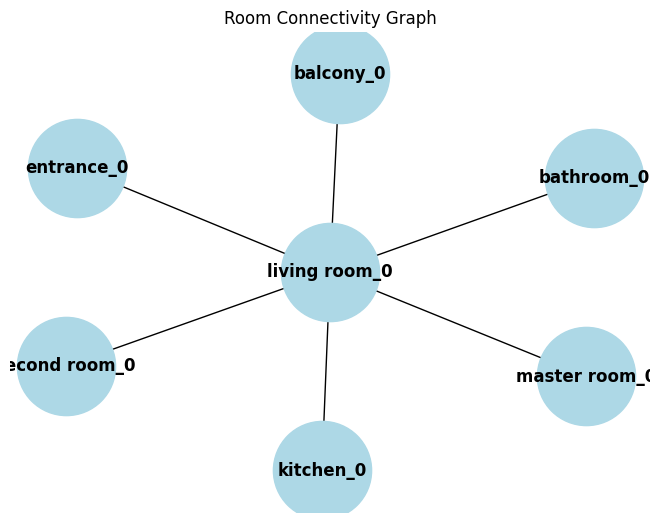

In [30]:
my_fp.draw_connectivity_graph()

And with this line of code we can show the connectivity graph on the plan

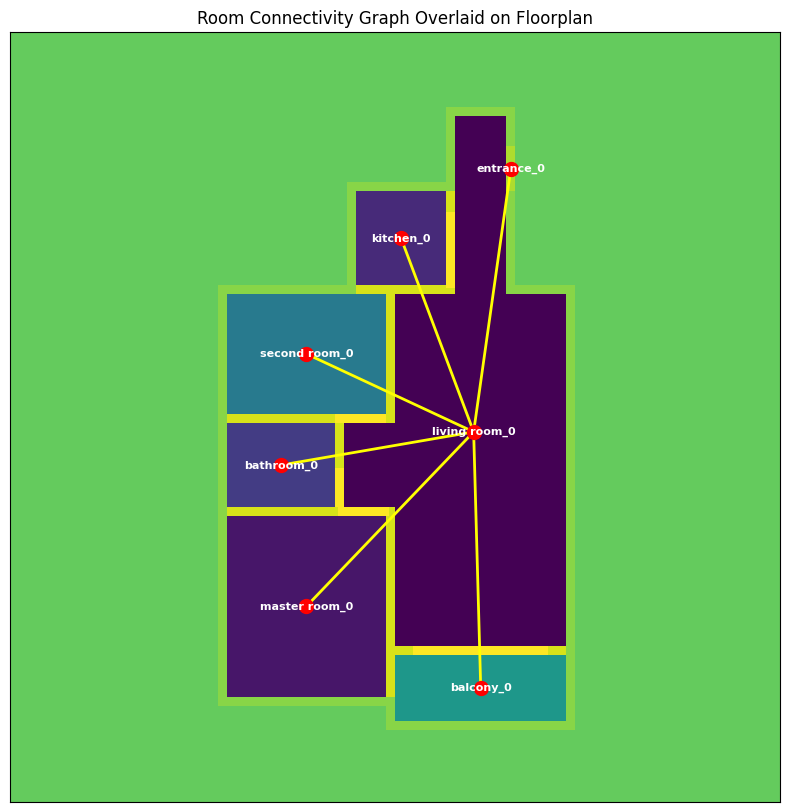

In [31]:
my_fp.draw_room_connectivity_on_plan()

Let's check some other qualities about the plans like listing the amount of the different rooms:

In [32]:
print(my_fp.get_room_types_count())

{'living room': 1, 'master room': 1, 'kitchen': 1, 'bathroom': 1, 'second room': 1, 'balcony': 1}


pixel-based shape: (16, 16, 3)


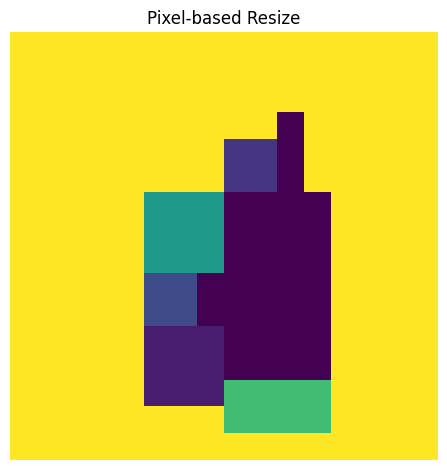

In [37]:
import matplotlib.pyplot as plt

size = 16

resized_fp_pixels = my_fp.outline_based_resize(size)

print("pixel-based shape:", resized_fp_pixels.shape)
plt.imshow(resized_fp_pixels[:,:,0])
plt.title('Pixel-based Resize')
plt.axis('off')
plt.tight_layout()
plt.show()

Now we can write a prompt to generate a description, taking also in account the connectivity graph and the names of the different rooms.

In [40]:
llm = ChatOpenAI(model="gpt-5.2-chat-latest")
system_message = "You are a helpful assistant that creates a text description of a floor plan based on the given data containing information about the room types, counts and how they are connected. Be concise and to the point, not too long or too poetic. Don't try to sell the flat and don't explain in detail what the rooms are for."
query = "Write a short descriptions like a prompt for a flat with the given features. The prompt should be in natural language and describe the the flat based on the given count of different room types and how they are connected. This is the data: "


In [41]:
data = my_fp.generate_llm_descriptions(llm, system_message, query)

for i, description in enumerate(data["descriptions"]):
    print(f"Description {i+1}:")
    print(description)
    print("\n")

Description 1:
A flat with one living room that connects directly to the entrance and serves as the central space. From the living room there is access to a master room, a second room, a kitchen, a bathroom, and a balcony. All main rooms are directly connected to the living room.


Description 2:
The flat has an entrance that opens directly into a central living room. The living room connects to two bedrooms, a bathroom, and a kitchen, making it the main hub of the layout. A balcony is also directly accessible from the living room. All rooms are connected through the living room without additional corridors.


Description 3:
The flat has a central living room connected directly to the entrance. From the living room there is access to the kitchen, bathroom, master room, second room, and a balcony. All main rooms are arranged around the living area with no additional corridors.






---


We can also do this in a loop to create descriptions for the whole dataset (or as seen here with the first 10):

In [42]:
import logging
import json
from tqdm import tqdm

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


OUTPUT_PATH = "./descriptions/"

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)


# you can set the max index here
max_index = 10

for i, path in tqdm(enumerate(paths[:max_index]), total=max_index):

    if i % 10 == 0:
        print(f"Processing {i} of {len(paths)}")

    try:
        my_fp = Floorplan(os.path.join(path), wall_width=wall_width)
        data = my_fp.generate_llm_descriptions(llm, system_message, query)

        # save the description
        with open(os.path.join(OUTPUT_PATH, f"description_{i}.json"), "w") as f:
            json.dump(data, f)
        logger.info(f"Processed {i} of {len(paths)}")

    except Exception as e:
        logger.error(f"Error processing plan {path}: {e}")


  0%|          | 0/10 [00:00<?, ?it/s]

Processing 0 of 100


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:Processed 0 of 100
 10%|█         | 1/10 [00:06<00:57,  6.34s/it]INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:Processed 1 of 100
 20%|██        | 2/10 [00:13<00:53,  6.71s/it]INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:Processed